In [3]:
from __future__ import print_function, division
from arch_config import *
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import copy
import kagglehub
import shutil
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights


In [4]:
from __future__ import print_function, division
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import copy
import kagglehub
import shutil

In [5]:
path = kagglehub.dataset_download(
    "gustavoachavez/architectural-styles-periods-dataset"
)
print("Kaggle cache path:", path)

destination_dir = "/data"

os.makedirs(destination_dir, exist_ok=True)

shutil.move(path, destination_dir)
print("Dataset moved to:", destination_dir)

100%|██████████| 1.98G/1.98G [00:20<00:00, 102MB/s]

Extracting files...


Kaggle cache path: /root/.cache/kagglehub/datasets/gustavoachavez/architectural-styles-periods-dataset/versions/1
Dataset moved to: /data


# Приведение данных к удобному виду (без поддиректорий)

In [6]:
!mv /data/architectural-styles-periods-dataset/Capstone_Architectural_Styles_dataset /data/arch_dataset

mv: cannot stat '/data/architectural-styles-periods-dataset/Capstone_Architectural_Styles_dataset': No such file or directory


In [7]:
!mkdir /data/arch_dataset/Capstone_Architectural_Styles_dataset

mkdir: cannot create directory ‘/data/arch_dataset/Capstone_Architectural_Styles_dataset’: No such file or directory


In [8]:
!mv /data/arch_dataset/21st_Century /data/arch_dataset/Baroque /data/arch_dataset/Classical /data/arch_dataset/Early_Christian_Medieval /data/arch_dataset/Modernism /data/arch_dataset/Neoclassicism /data/arch_dataset/Renaissance_and_Colonialism /data/arch_dataset/Revivalism /data/arch_dataset/Capstone_Architectural_Styles_dataset

mv: target '/data/arch_dataset/Capstone_Architectural_Styles_dataset' is not a directory


In [9]:
!mv /data/arch_dataset/Eclecticism /data/arch_dataset/

mv: cannot stat '/data/arch_dataset/Eclecticism': No such file or directory


In [10]:
!ls -al /data/arch_dataset

ls: cannot access '/data/arch_dataset': No such file or directory


In [12]:
source_root = '/data/arch_dataset/Capstone_Architectural_Styles_dataset'

flat_root = '/data/arch_dataset/flat_dataset'
os.makedirs(flat_root, exist_ok=True)

classes = os.listdir(source_root)

for class_name in classes:
    class_dir = os.path.join(flat_root, class_name)
    os.makedirs(class_dir, exist_ok=True)

image_extensions = ('.jpg', '.jpeg', '.png')

for class_name in classes:
    source_class_path = os.path.join(source_root, class_name)
    target_class_path = os.path.join(flat_root, class_name)

    print(f"Processing {class_name}...")

    count = 0
    for root, _, files in os.walk(source_class_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                src_file = os.path.join(root, file)
                dst_file = os.path.join(target_class_path, file)

                if not os.path.exists(dst_file):
                    shutil.copy2(src_file, dst_file)
                    count += 1

    print(f"  → {count} изображений скопировано в {class_name}")


Processing Classical...
  → 1022 изображений скопировано в Classical
Processing Renaissance_and_Colonialism...
  → 1294 изображений скопировано в Renaissance_and_Colonialism
Processing Modernism...
  → 1860 изображений скопировано в Modernism
Processing Neoclassicism...
  → 1225 изображений скопировано в Neoclassicism
Processing Baroque...
  → 1089 изображений скопировано в Baroque
Processing Early_Christian_Medieval...
  → 1338 изображений скопировано в Early_Christian_Medieval
Processing Revivalism...
  → 1919 изображений скопировано в Revivalism
Processing 21st_Century...
  → 1229 изображений скопировано в 21st_Century
Processing Eclecticism...
  → 1315 изображений скопировано в Eclecticism


# Приведение данных к удобному виду (без поддиректорий)

In [13]:
!mv /data/1 /data/arch_dataset

mv: cannot stat '/data/1': No such file or directory


In [14]:
!ls -al /data/arch_dataset

total 16
drwxr-xr-x  4 root root 4096 Feb 17 14:23 .
drwxr-xr-x  4 root root 4096 Feb 17 14:23 ..
drwxr-xr-x 11 root root 4096 Feb 17 14:22 Capstone_Architectural_Styles_dataset
drwxr-xr-x 11 root root 4096 Feb 17 14:23 flat_dataset


In [15]:
source_root = '/data/arch_dataset/Capstone_Architectural_Styles_dataset'

flat_root = '/data/arch_dataset/flat_dataset'
os.makedirs(flat_root, exist_ok=True)

classes = os.listdir(source_root)

for class_name in classes:
    class_dir = os.path.join(flat_root, class_name)
    os.makedirs(class_dir, exist_ok=True)

image_extensions = ('.jpg', '.jpeg', '.png')

for class_name in classes:
    source_class_path = os.path.join(source_root, class_name)
    target_class_path = os.path.join(flat_root, class_name)

    print(f"Processing {class_name}...")

    count = 0
    for root, _, files in os.walk(source_class_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                src_file = os.path.join(root, file)
                dst_file = os.path.join(target_class_path, file)

                if not os.path.exists(dst_file):
                    shutil.copy2(src_file, dst_file)
                    count += 1

    print(f"  → {count} изображений скопировано в {class_name}")


Processing Classical...
  → 0 изображений скопировано в Classical
Processing Renaissance_and_Colonialism...
  → 0 изображений скопировано в Renaissance_and_Colonialism
Processing Modernism...
  → 0 изображений скопировано в Modernism
Processing Neoclassicism...
  → 0 изображений скопировано в Neoclassicism
Processing Baroque...
  → 0 изображений скопировано в Baroque
Processing Early_Christian_Medieval...
  → 0 изображений скопировано в Early_Christian_Medieval
Processing Revivalism...
  → 0 изображений скопировано в Revivalism
Processing 21st_Century...
  → 0 изображений скопировано в 21st_Century
Processing Eclecticism...
  → 0 изображений скопировано в Eclecticism


# Визуализация дисбаланса в данных

In [16]:
def count_images(main_root):
    counts = []
    for dirname in os.listdir(main_root):
        class_path = f'{main_root}/{dirname}'
        if os.path.isdir(class_path):
            total_files = sum(len(files) for _, _, files in os.walk(class_path))
            counts.append(total_files)
            print(f'{dirname}: {total_files}')
    return counts

In [17]:
import pandas as pd

source_root = '/data/arch_dataset/Capstone_Architectural_Styles_dataset'

flat_root = '/data/arch_dataset/flat_dataset'
classes = os.listdir(source_root)

styles_df = pd.DataFrame({
    'style': classes,
    'images': count_images(source_root) # [len(os.listdir(os.path.join(flat_root, cls))) for cls in classes]
})
styles_df

Classical: 1022
Renaissance_and_Colonialism: 1294
Modernism: 1860
Neoclassicism: 1225
Baroque: 1089
Early_Christian_Medieval: 1338
Revivalism: 1919
21st_Century: 1229
Eclecticism: 1315


,style,images
0,Classical,1022
1,Renaissance_and_Colonialism,1294
2,Modernism,1860
3,Neoclassicism,1225
4,Baroque,1089
5,Early_Christian_Medieval,1338
6,Revivalism,1919
7,21st_Century,1229
8,Eclecticism,1315


In [18]:
import plotly.express as px

plot = px.bar(styles_df, x='style', y='images', title='Image count per style. Disbalance visualisation')
plot.show()

# Разделение на тренировочную, валидационную и тестовую выборки

In [19]:
from sklearn.model_selection import train_test_split
import random

for split in ['train', 'val', 'test']:
    split_path = os.path.join(flat_root, split)
    os.makedirs(split_path, exist_ok=True)

random.seed(42)

print("Splitting classes...")
for class_name in classes:
    print(f"  {class_name}...")

    class_path = os.path.join(flat_root, class_name)
    files = os.listdir(class_path)

    train_files, temp_files = train_test_split(files, train_size=0.8, random_state=42)
    val_files, test_files = train_test_split(temp_files, train_size=0.5, random_state=42)

    for split_name, split_files in [('train', train_files), ('val', val_files), ('test', test_files)]:
        src_dir = class_path
        dst_dir = os.path.join(flat_root, split_name, class_name)
        os.makedirs(dst_dir, exist_ok=True)

        for file in split_files:
            shutil.move(os.path.join(src_dir, file), os.path.join(dst_dir, file))

    print(f"    → train: {len(train_files)}, val: {len(val_files)}, test: {len(test_files)}")

    if not os.listdir(class_path):
        os.rmdir(class_path)
        print(f"Deleted empty dir: {class_name}")

Splitting classes...
  Classical...
    → train: 817, val: 102, test: 103
Deleted empty dir: Classical
  Renaissance_and_Colonialism...
    → train: 1035, val: 129, test: 130
Deleted empty dir: Renaissance_and_Colonialism
  Modernism...
    → train: 1488, val: 186, test: 186
Deleted empty dir: Modernism
  Neoclassicism...
    → train: 980, val: 122, test: 123
Deleted empty dir: Neoclassicism
  Baroque...
    → train: 871, val: 109, test: 109
Deleted empty dir: Baroque
  Early_Christian_Medieval...
    → train: 1070, val: 134, test: 134
Deleted empty dir: Early_Christian_Medieval
  Revivalism...
    → train: 1535, val: 192, test: 192
Deleted empty dir: Revivalism
  21st_Century...
    → train: 983, val: 123, test: 123
Deleted empty dir: 21st_Century
  Eclecticism...
    → train: 1052, val: 131, test: 132
Deleted empty dir: Eclecticism


# Преобразование данных в тензоры + аугментация

In [20]:
# Make transforms and use data loaders # We'll use these a lot, so make them variables
mean_nums = [0.485, 0.456, 0.406]
std_nums = [0.229, 0.224, 0.225]
chosen_transforms = {'train': transforms.Compose([ transforms.RandomResizedCrop(size=256), transforms.RandomRotation(degrees=15), transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize(mean_nums, std_nums) ]), 'val': transforms.Compose([ transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(), transforms.Normalize(mean_nums, std_nums) ]), 'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean_nums, std_nums)
    ])}

In [21]:
data_dir = flat_root

chosen_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), chosen_transforms[x]) for x in ['train', 'val', 'test']}

In [22]:
dataloaders = {x: torch.utils.data.DataLoader(chosen_datasets[x], batch_size=4, shuffle=(x == 'train'), num_workers=4) for x in ['train', 'val', 'test']}

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.



In [23]:
dataset_sizes = {x: len(chosen_datasets[x]) for x in ['train', 'val', 'test']}
class_names = chosen_datasets['train'].classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(dataset_sizes, class_names, device)

{'train': 9831, 'val': 1228, 'test': 1232} ['21st_Century', 'Baroque', 'Classical', 'Early_Christian_Medieval', 'Eclecticism', 'Modernism', 'Neoclassicism', 'Renaissance_and_Colonialism', 'Revivalism'] cuda


In [24]:
# Visualize some images
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array(mean_nums)
    std = np.array(std_nums)
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    #plt.pause(0.001)

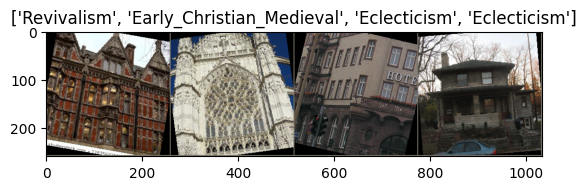

In [25]:
# Grab some of the training data to visualize
inputs, classes = next(iter(dataloaders['train']))
# Now we construct a grid from batch
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

In [26]:
dataloaders, class_names, dataset_sizes, vis_loader = get_dataloaders()
train_set, val_set, test_set = dataloaders['train'], dataloaders['val'], dataloaders['test']

wide_model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
for param in wide_model.features[0].parameters():
    param.requires_grad = False
for param in wide_model.features[1].parameters():
    param.requires_grad = False
num_ftrs = wide_model.classifier[1].in_features

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 161MB/s]


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
wide_model.classifier = nn.Sequential(
    nn.Linear(1280, 2048),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 9)
)
wide_model = wide_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_wide = torch.optim.AdamW(wide_model.parameters(), lr=0.0001, weight_decay=0.01)
exp_lr_scheduler_wide = lr_scheduler.CosineAnnealingLR(optimizer_wide, T_max=30)

In [29]:
wide_model_trained, metrics_wide = train_model(
    wide_model,
    criterion,
    optimizer_wide,
    exp_lr_scheduler_wide,
    dataloaders,
    dataset_sizes,
    num_epochs=25)

Epoch 1/25
----------
Iterating through data...
train Loss: 1.4583 | Acc: 0.4756 | Weighted Acc: 0.3904 | F1-macro: 0.4608 | Top-1 Acc: 0.4756 | Top-3 Acc: 0.7710
Iterating through data...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.



val Loss: 0.8763 | Acc: 0.6897 | Weighted Acc: 0.6446 | F1-macro: 0.6837 | Top-1 Acc: 0.6897 | Top-3 Acc: 0.9202
Epoch Time: 165.9988s

Epoch 2/25
----------
Iterating through data...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.



train Loss: 0.9270 | Acc: 0.6802 | Weighted Acc: 0.6388 | F1-macro: 0.6789 | Top-1 Acc: 0.6802 | Top-3 Acc: 0.9134
Iterating through data...


...

val Loss: 1.0314 | Acc: 0.7769 | Weighted Acc: 0.7501 | F1-macro: 0.7777 | Top-1 Acc: 0.7769 | Top-3 Acc: 0.9577
Epoch Time: 160.7917s

Epoch 25/25
----------
Iterating through data...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.



train Loss: 0.0857 | Acc: 0.9701 | Weighted Acc: 0.9666 | F1-macro: 0.9703 | Top-1 Acc: 0.9701 | Top-3 Acc: 0.9988
Iterating through data...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.



val Loss: 1.0206 | Acc: 0.7728 | Weighted Acc: 0.7500 | F1-macro: 0.7758 | Top-1 Acc: 0.7728 | Top-3 Acc: 0.9560
Epoch Time: 160.3440s

Training complete in 69m 5s
Best val Weighted Acc: 0.759692 | Best F1-score: 0.7886 | Best Top-1 Acc: 0.7858 | Best Top-3 Acc: 0.9520


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.



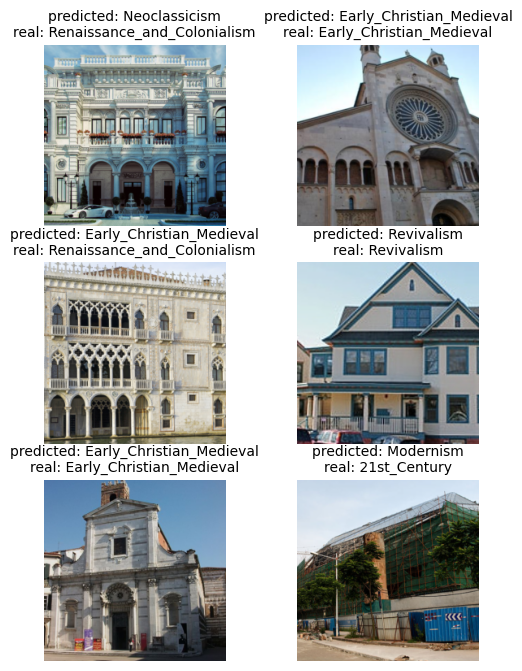

In [30]:
visualize_model(wide_model_trained, num_images=6, class_names=class_names, vis_loader=vis_loader)

In [31]:
def visualize_metrics1(metrics, title, epochs=25):
    x = list(range(1, epochs + 1))
    accuracy_train, f1_train, top3_train, top1_train, loss_train, accuracy_val, f1_val, top3_val, top1_val, loss_val = metrics

    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=("Weighted accuracy", "F1-score macro", "Top-3 Accuracy", "Top-1 Accuracy", "Top-1 vs Top-3 Validation Accuracy", "Loss function"),
        horizontal_spacing=0.08,
        vertical_spacing=0.2)

    # Accuracy (1,1) — своя легенда "legend1"
    fig.add_trace(go.Scatter(x=x, y=accuracy_train, name='train',
                             legend="legend1", legendgroup="acc1"), row=1, col=1)
    fig.add_trace(go.Scatter(x=x, y=accuracy_val, name='val',
                             legend="legend1", legendgroup="acc1"), row=1, col=1)

    # F1 (1,2) — своя легенда "legend2"
    fig.add_trace(go.Scatter(x=x, y=f1_train, name='train',
                             legend="legend2", legendgroup="f1"), row=1, col=2)
    fig.add_trace(go.Scatter(x=x, y=f1_val, name='val',
                             legend="legend2", legendgroup="f1"), row=1, col=2)

    # Top-3 (1,3) — "legend3"
    fig.add_trace(go.Scatter(x=x, y=top3_train, name='train',
                             legend="legend3", legendgroup="top3"), row=1, col=3)
    fig.add_trace(go.Scatter(x=x, y=top3_val, name='val',
                             legend="legend3", legendgroup="top3"), row=1, col=3)

    # Top-1 (2,1) — "legend4"
    fig.add_trace(go.Scatter(x=x, y=top1_train, name='train',
                             legend="legend4", legendgroup="top1"), row=2, col=1)
    fig.add_trace(go.Scatter(x=x, y=top1_val, name='val',
                             legend="legend4", legendgroup="top1"), row=2, col=1)

    # vs (2,2) - "legend5"
    fig.add_trace(go.Scatter(x=x, y=top1_val, name='train',
                             legend="legend5", legendgroup="vs"), row=2, col=2)
    fig.add_trace(go.Scatter(x=x, y=top3_val, name='val',
                             legend="legend5", legendgroup="vs"), row=2, col=2)

    # Loss (2,3) — "legend6"
    fig.add_trace(go.Scatter(x=x, y=loss_train, name='train',
                             legend="legend6", legendgroup="loss"), row=2, col=3)
    fig.add_trace(go.Scatter(x=x, y=loss_val, name='val',
                             legend="legend6", legendgroup="loss"), row=2, col=3)

    for i in range(1, 3):
        for j in range(1, 4):
            fig.update_xaxes(title_text="Epoch", row=i, col=j)
            fig.update_yaxes(title_text="Metric value", row=i, col=j)

    fig.update_layout(title_text=title, height=800, width=1200,
                      legend1=dict(x=0.2, y=0.7, xanchor="left", yanchor="top"),
                      legend2=dict(x=0.63, y=0.7, xanchor="right", yanchor="top"),
                      legend3=dict(x=0.95, y=0.62, xanchor="left", yanchor="bottom"),
                      legend4=dict(x=0.28, y=0.01, xanchor="right", yanchor="bottom"),
                      legend5=dict(x=0.63, y=0.00, xanchor="right", yanchor="bottom"),
                      legend6=dict(x=0.99, y=0.3, xanchor="right", yanchor="bottom"),
                      dragmode="pan",)
    fig.show()

In [34]:
visualize_metrics1(metrics_wide, "Metics: Wide", 25)

NameError: name 'make_subplots' is not defined

In [33]:
torch.save(wide_model_trained.state_dict(), 'wide_head_model.pt')

In [35]:
# Сначала импортируем необходимые библиотеки
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def visualize_metrics1(metrics, title, epochs=25):
    x = list(range(1, epochs + 1))
    accuracy_train, f1_train, top3_train, top1_train, loss_train, accuracy_val, f1_val, top3_val, top1_val, loss_val = metrics

    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=("Weighted accuracy", "F1-score macro", "Top-3 Accuracy", "Top-1 Accuracy", "Top-1 vs Top-3 Validation Accuracy", "Loss function"),
        horizontal_spacing=0.08,
        vertical_spacing=0.2)

    # Accuracy (1,1) — своя легенда "legend1"
    fig.add_trace(go.Scatter(x=x, y=accuracy_train, name='train',
                             legend="legend1", legendgroup="acc1"), row=1, col=1)
    fig.add_trace(go.Scatter(x=x, y=accuracy_val, name='val',
                             legend="legend1", legendgroup="acc1"), row=1, col=1)

    # F1 (1,2) — своя легенда "legend2"
    fig.add_trace(go.Scatter(x=x, y=f1_train, name='train',
                             legend="legend2", legendgroup="f1"), row=1, col=2)
    fig.add_trace(go.Scatter(x=x, y=f1_val, name='val',
                             legend="legend2", legendgroup="f1"), row=1, col=2)

    # Top-3 (1,3) — "legend3"
    fig.add_trace(go.Scatter(x=x, y=top3_train, name='train',
                             legend="legend3", legendgroup="top3"), row=1, col=3)
    fig.add_trace(go.Scatter(x=x, y=top3_val, name='val',
                             legend="legend3", legendgroup="top3"), row=1, col=3)

    # Top-1 (2,1) — "legend4"
    fig.add_trace(go.Scatter(x=x, y=top1_train, name='train',
                             legend="legend4", legendgroup="top1"), row=2, col=1)
    fig.add_trace(go.Scatter(x=x, y=top1_val, name='val',
                             legend="legend4", legendgroup="top1"), row=2, col=1)

    # vs (2,2) - "legend5" — исправлено: правильные названия для легенды
    fig.add_trace(go.Scatter(x=x, y=top1_val, name='Top-1',
                             legend="legend5", legendgroup="vs"), row=2, col=2)
    fig.add_trace(go.Scatter(x=x, y=top3_val, name='Top-3',
                             legend="legend5", legendgroup="vs"), row=2, col=2)

    # Loss (2,3) — "legend6"
    fig.add_trace(go.Scatter(x=x, y=loss_train, name='train',
                             legend="legend6", legendgroup="loss"), row=2, col=3)
    fig.add_trace(go.Scatter(x=x, y=loss_val, name='val',
                             legend="legend6", legendgroup="loss"), row=2, col=3)

    for i in range(1, 3):
        for j in range(1, 4):
            fig.update_xaxes(title_text="Epoch", row=i, col=j)
            fig.update_yaxes(title_text="Metric value", row=i, col=j)

    fig.update_layout(title_text=title, height=800, width=1200,
                      legend1=dict(x=0.2, y=0.7, xanchor="left", yanchor="top"),
                      legend2=dict(x=0.63, y=0.7, xanchor="right", yanchor="top"),
                      legend3=dict(x=0.95, y=0.62, xanchor="left", yanchor="bottom"),
                      legend4=dict(x=0.28, y=0.01, xanchor="right", yanchor="bottom"),
                      legend5=dict(x=0.63, y=0.00, xanchor="right", yanchor="bottom"),
                      legend6=dict(x=0.99, y=0.3, xanchor="right", yanchor="bottom"),
                      dragmode="pan",)
    fig.show()

In [36]:
visualize_metrics1(metrics_wide, "Metrics: Wide (EfficientNet-B0 + Freeze 2 layers + AdamW)", 25)